<div style="background: linear-gradient(135deg, #2D6A4F 0%, #2D6A4F 100%); padding: 24px; border-radius: 12px; color: white;">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Hotel Booking Project</h1>
    <div style="background: rgba(255, 255, 255, 0.15); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Question:</strong> What trends can we see in the data?
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

all_dfs = pd.read_pickle('all_clean_dfs2.pkl')
df = all_dfs['df']
clean_df = all_dfs['clean_df']

In [2]:
print(clean_df.columns)

Index(['hotel_type', 'is_cancelled', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_cancelled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'arrival_date'],
      dtype='object')


In [3]:
#hotel_type pivot table

hotel_type_pivot_df = pd.pivot_table(
    clean_df,
    index='hotel_type',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

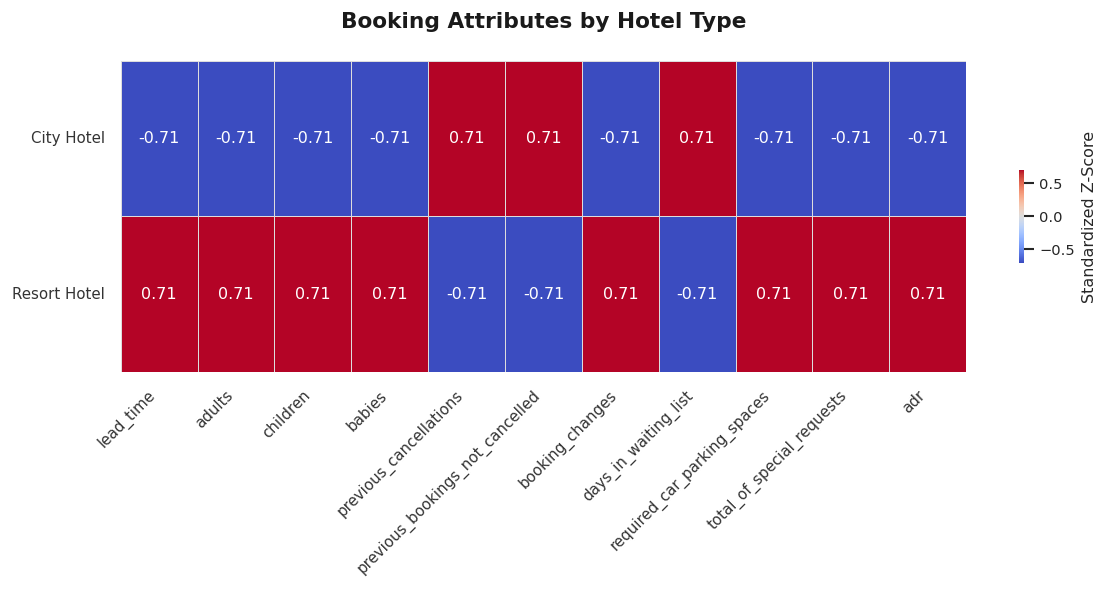

In [4]:
#hotel_type heatmap


# Standardize to Z-scores
matrix_zscore = hotel_type_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Hotel Type",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [5]:
#meal pivot table

meal_pivot_df = pd.pivot_table(
    clean_df,
    index='meal',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

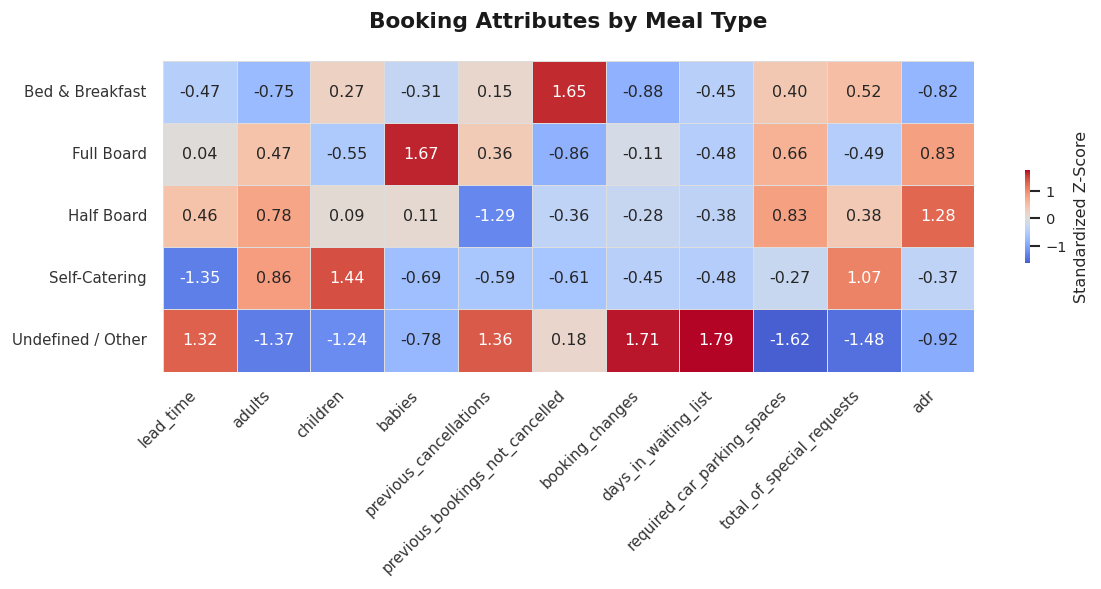

In [6]:
#meal heatmap


# Standardize to Z-scores
matrix_zscore = meal_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Meal Type",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [7]:
pd.set_option('display.max_rows', None)
print(clean_df["country"].value_counts())

country
PRT    6049
ESP    1285
GBR     936
FRA     892
DEU     339
IRL     328
ITA     327
NLD     173
BEL     152
USA     150
BRA     131
CHE     119
POL      81
AUT      81
CN       81
RUS      62
SWE      59
ISR      46
AGO      44
ROU      40
FIN      39
NOR      39
CHN      35
AUS      26
DNK      25
JPN      25
LUX      23
GRC      22
CZE      20
MAR      19
TUR      18
MEX      17
HUN      17
IND      16
ARG      13
LTU      13
DZA      12
KOR      11
LVA      10
IRN      10
NZL       9
UKR       8
HRV       8
LBN       7
BLR       7
SVN       7
CHL       7
MOZ       6
CRI       6
IRQ       6
VEN       6
SRB       5
MYS       5
EGY       5
TUN       5
COL       4
SVK       4
BGR       4
JOR       4
SGP       4
TWN       3
OMN       3
ZAF       3
KAZ       3
THA       3
CMR       3
SAU       3
DOM       2
MUS       2
LKA       2
PRI       2
NGA       2
CPV       2
ALB       2
AZE       2
IDN       2
EST       2
MMR       1
PAN       1
PHL       1
LIE       1
ZMB       1
CYM     

In [8]:
#country pivot table

top_n = 15
top_countries = clean_df['country'].value_counts().head(top_n).index
filtered_country_df = clean_df[clean_df['country'].isin(top_countries)]

country_pivot_df = pd.pivot_table(
    filtered_country_df,
    index='country',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

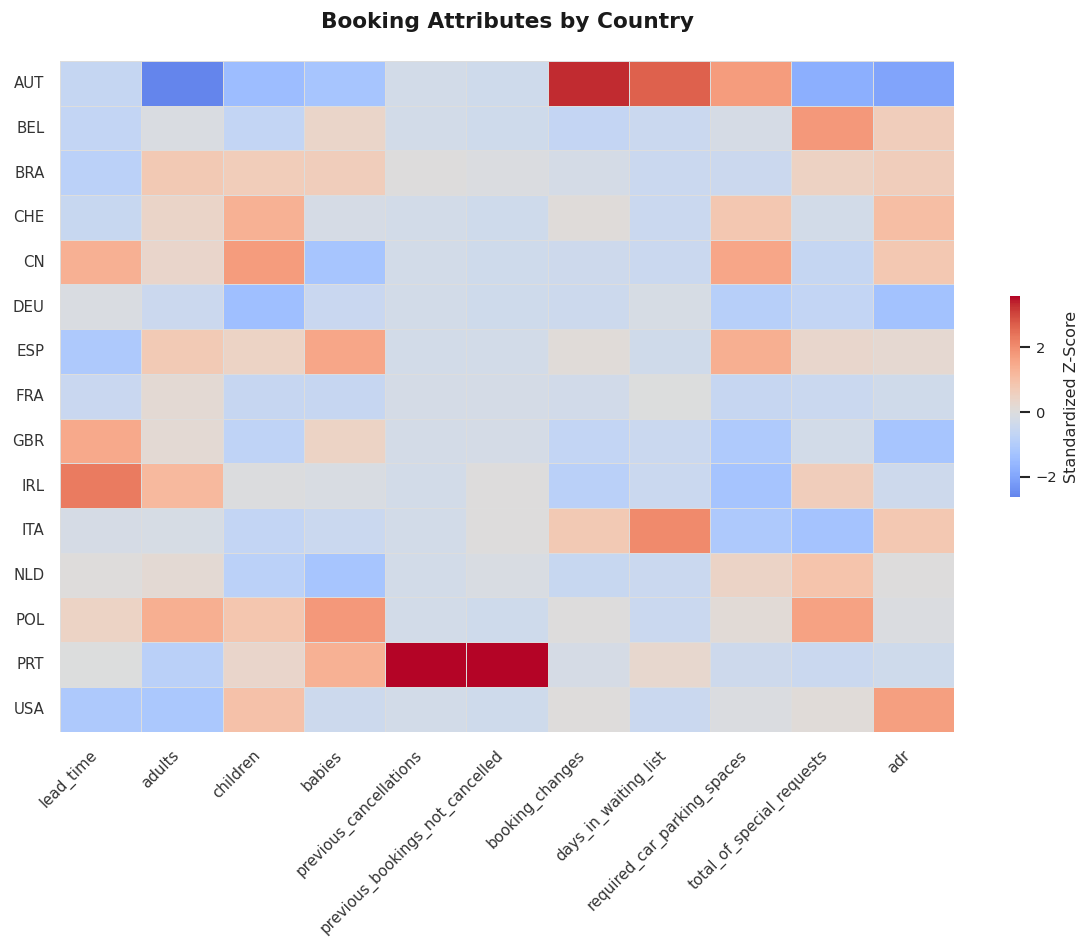

In [9]:
#country heatmap


# Standardize to Z-scores
matrix_zscore = country_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 8), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=False,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Country",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [10]:
#market_segment pivot table

market_segment_pivot_df = pd.pivot_table(
    clean_df,
    index='market_segment',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

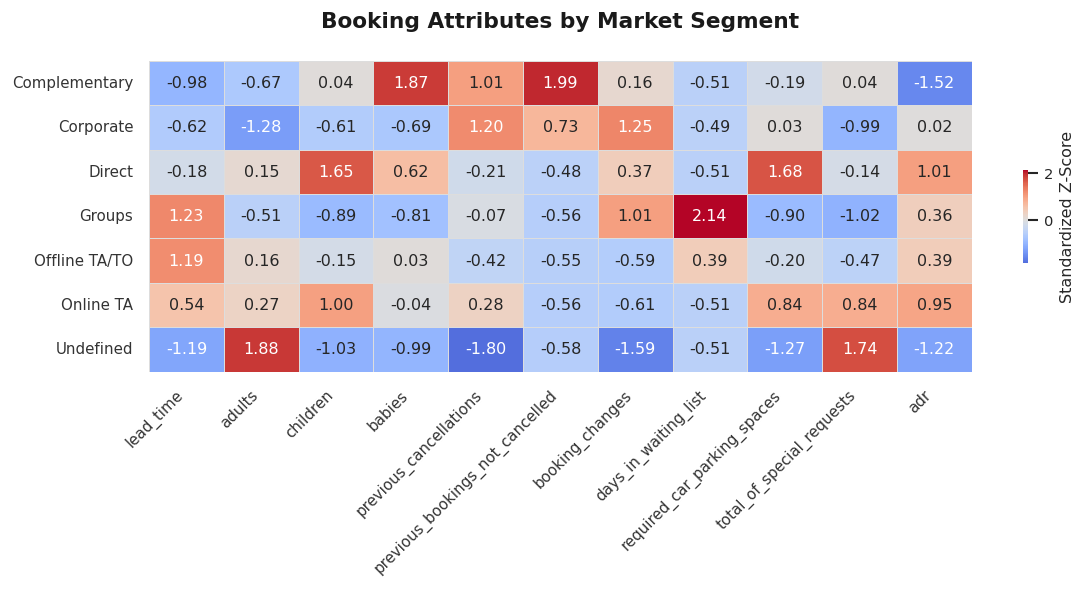

In [11]:
#market_segment heatmap


# Standardize to Z-scores
matrix_zscore = market_segment_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Market Segment",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [12]:
#distribution_channel pivot table

distribution_channel_pivot_df = pd.pivot_table(
    clean_df,
    index='distribution_channel',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

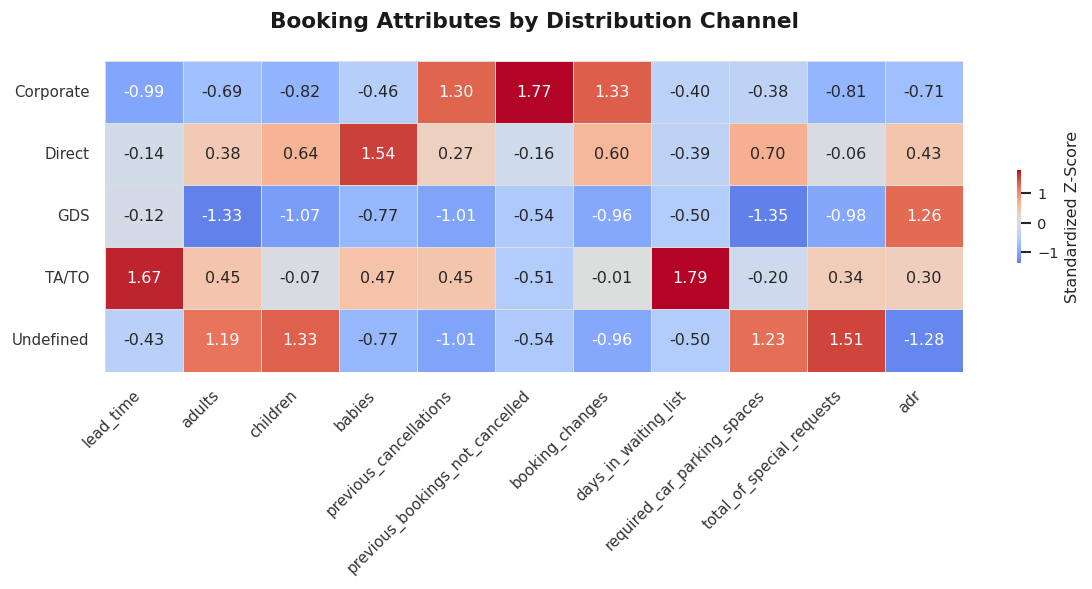

In [13]:
#distribution_channel heatmap


# Standardize to Z-scores
matrix_zscore = distribution_channel_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Distribution Channel",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [14]:
#reserved_room_type pivot table

reserved_room_type_pivot_df = pd.pivot_table(
    clean_df,
    index='reserved_room_type',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

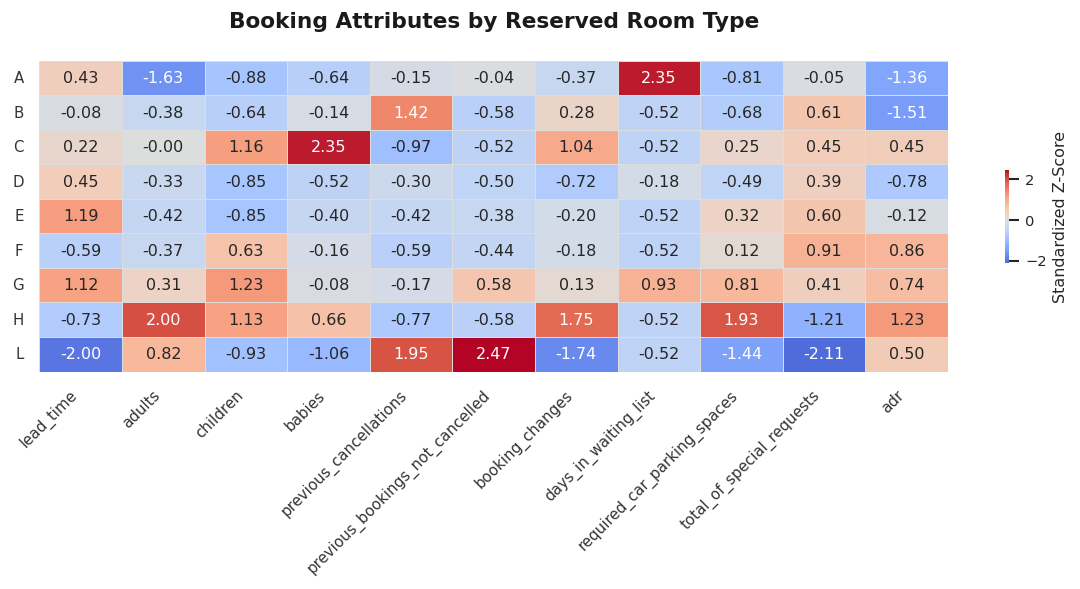

In [15]:
#reserved_room_type heatmap


# Standardize to Z-scores
matrix_zscore = reserved_room_type_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score", 
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Reserved Room Type",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [16]:
#assigned_room_type pivot table

assigned_room_type_pivot_df = pd.pivot_table(
    clean_df,
    index='assigned_room_type',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

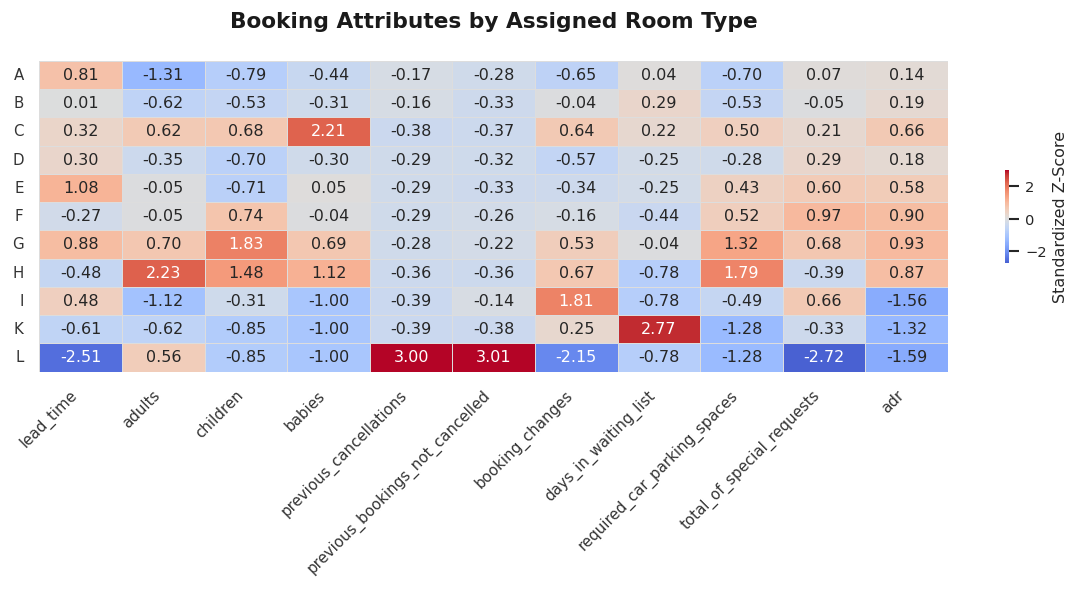

In [17]:
#assigned_room_type heatmap


# Standardize to Z-scores
matrix_zscore = assigned_room_type_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Assigned Room Type",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [18]:
#deposit_type pivot table

deposit_type_pivot_df = pd.pivot_table(
    clean_df,
    index='deposit_type',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

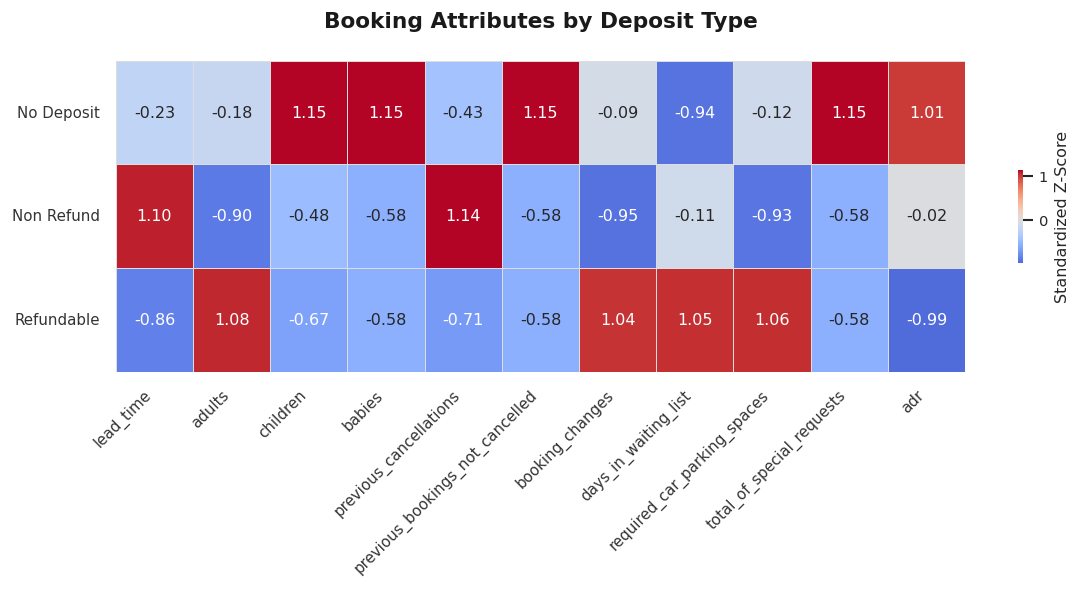

In [19]:
#deposit_type heatmap


# Standardize to Z-scores
matrix_zscore = deposit_type_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Deposit Type",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [20]:
#customer_type pivot table

customer_type_pivot_df = pd.pivot_table(
    clean_df,
    index='customer_type',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

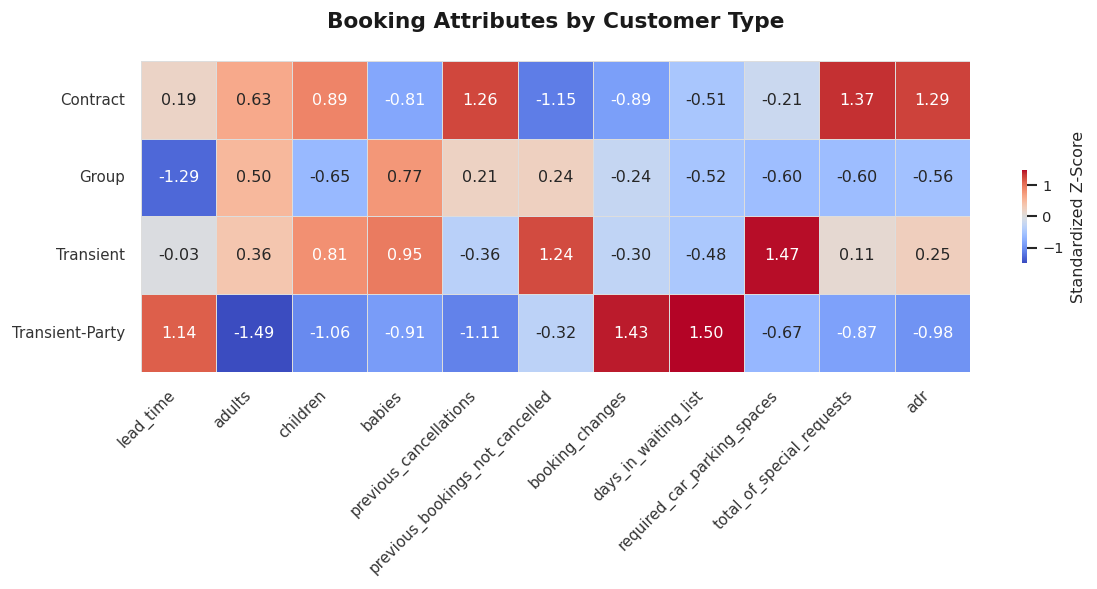

In [21]:
#customer_type heatmap


# Standardize to Z-scores
matrix_zscore = customer_type_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Customer Type",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [22]:
#reservation_status pivot table

reservation_status_pivot_df = pd.pivot_table(
    clean_df,
    index='reservation_status',
    values=('lead_time',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_cancelled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'adr'))

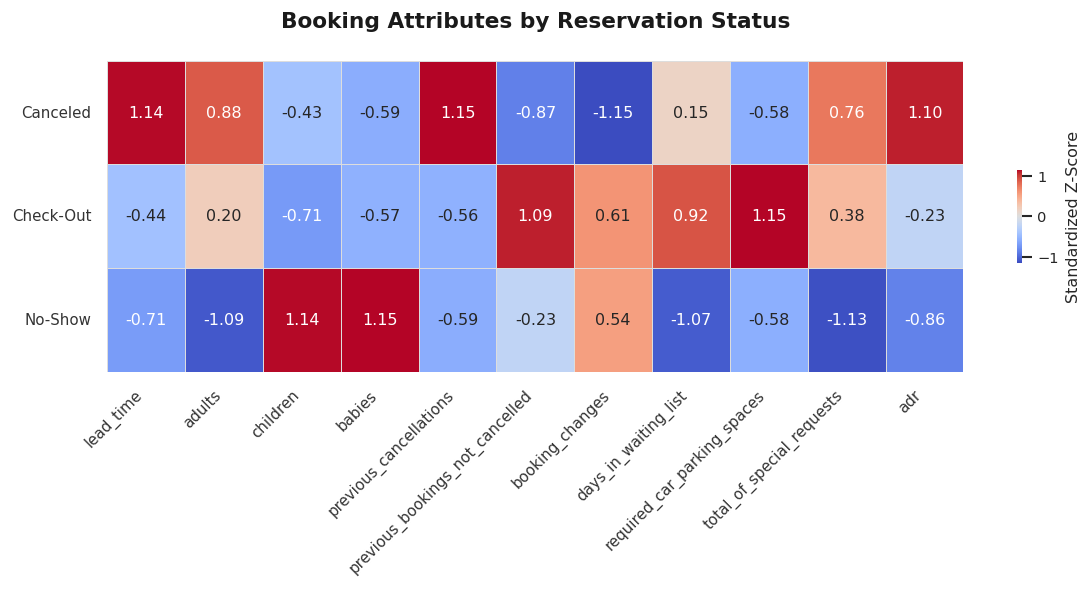

In [23]:
#reservation_status heatmap


# Standardize to Z-scores
matrix_zscore = reservation_status_pivot_df.apply(lambda x: (x - x.mean()) / x.std())

# Variables for heatmap
selected_variables = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_cancelled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "adr",
]

# Filter to variables
matrix_subset = matrix_zscore[selected_variables]

# Colormap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#F4F4F4")

# Plot Heatmap
plt.figure(figsize=(10, 5), dpi=120)
sns.set_theme(style="white", font_scale=0.8)

ax = sns.heatmap(
    matrix_subset,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".2f",
    square=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Z-Score",
        "shrink": 0.3,
    },
)

# Titles & format
plt.title(
    "Booking Attributes by Reservation Status",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",
)

#labels
plt.xlabel(
    "", fontsize=10, fontweight="bold", labelpad=10
)
plt.ylabel("", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=9, color="#333333")

plt.tight_layout()
plt.show()

In [6]:
from IPython.display import HTML, display

html_content = """

    
    <div style="background: linear-gradient(135deg, #2D6A4F 0%, #2D6A4F 100%); padding: 20px 24px; border-radius: 10px; color: white; margin-bottom: 20px;">
        <h1 style="margin: 0 0 6px 0; color: #ffffff; font-size: 22px; font-weight: 800; border-bottom: none; padding: 0;">Trends Conclusions</h1>
        <div style="font-size: 13px; color: #white; opacity: 0.95; line-height: 1.5;">Guests from different countries exhibit distinct needs and booking patterns. For instance,
        travelers from Poland tend to be more family-oriented, while Portugal shows a unique pattern by leading in both previous cancellations and past bookings that were successfully completed.<br>
Guest types also display unique behaviors. Corporate travelers frequently submit special requests but rarely travel with children, whereas groups typically book well in advance and experience
multiple booking changes.<br>
As for cancellation trends, non-refundable bookings surprisingly correlate with the highest rates of cancellation. Overall cancellation and no-show risks spike when lead times are long,
guests have a history of prior cancellations, or daily rates are high. Furthermore, no-shows frequently involve families with children and babies, likely due to unforeseen circumstances disrupting
travel plans.<br>
        
        </div>
    </div>
</div>
"""

display(HTML(html_content))